In [2]:
import os
import re
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt


In [3]:
class PRPDMetrics():

    def __init__(self, PRPD: np.ndarray):
        """
        Inicializa a classe com um array.

        Args:
            PRPD(ndarray): Array NumPy contendo valores de amplitude e fase.
        """

        if not isinstance(PRPD, np.ndarray): # Validações de entrada
            raise TypeError("PRPD deve ser um array NumPy.")
        
        if PRPD.shape[1] == 0:
            self.PRPD = PRPD   
            self._minimum = 0 # prefixo _ indica que são variáveis internas (convenção Python)
            self._maximum = 0
            self._elements = 0
            self._mean = 0
            self._Firstquartile = 0
            self._Secondquartile = 0
            self._Thirdquartile = 0
            self._Assymetry = 0
            self._Kurtosis = 0
            self._dataframe = 0

        else:   
            self.PRPD = PRPD   
            self._minimum = None # prefixo _ indica que são variáveis internas (convenção Python)
            self._maximum = None
            self._elements = None
            self._mean = None
            self._Firstquartile = None
            self._Secondquartile = None
            self._Thirdquartile = None
            self._Assymetry = None
            self._Kurtosis = None
            self._dataframe = None

    @property # permite acessar o método como se fosse um atributo (sem parênteses)
    def minimum(self) -> float:
        """Calcula e retorna o valor minimo dos vetores de amplitudes e fases"""
        if self._minimum is None:
            self._minimum = np.min(self.PRPD, axis=1)
        return self._minimum
    
    @property
    def maximum(self) -> float:
        """Calcula e retorna o valor maximo dos vetores de amplitude e fase"""
        if self._maximum is None:
            self._maximum = np.max(self.PRPD, axis=1)
        return self._maximum
    
    @property
    def elements(self) -> float:
        """Calcula e retorna a quantidade de pulsos"""
        if self._elements is None:
            self._elements = self.PRPD.shape[1]
        return self._elements
    
    @property
    def mean(self) -> float:
        """Calcula e retorna a media dos amplitudes e fases"""
        if self._mean is None:
            self._mean = np.mean(self.PRPD, axis=1)
        return self._mean
    
    @property
    def firstquartile(self) -> float:
        """Calcula e retorna o primeiro quartil das amplitudes e fases"""
        if self._Firstquartile is None:
            self._Firstquartile = np.percentile(self.PRPD, 25, axis=1)
        return self._Firstquartile
    
    @property
    def secondquartile(self) -> float:
        """Calcula e retorna o segundo quartil das amplitudes e fases"""
        if self._Secondquartile is None:
            self._Secondquartile = np.percentile(self.PRPD, 50, axis=1)
        return self._Secondquartile
    
    @property
    def thirdquartile(self) -> float:
        """Calcula e retorna o terceiro quartil das amplitudes e fases"""
        if self._Thirdquartile is None:
            self._Thirdquartile = np.percentile(self.PRPD, 75, axis=1)
        return self._Thirdquartile
    
    @property
    def assymetry(self) -> float:
        """Calcula e retorna o assimetria das amplitudes e fases"""
        if self._Assymetry is None:
            self._Assymetry = scipy.stats.skew(self.PRPD, axis=1)
        return self._Assymetry
    
    @property
    def kurtosis(self) -> float:
        """Calcula e retorna a curtose das amplitudes e fases"""
        if self._Kurtosis is None:
            self._Kurtosis = scipy.stats.kurtosis(self.PRPD, axis=1)
        return self._Kurtosis  
    
    @property
    def dataframe(self) -> pd.DataFrame:
        """Retorna um DataFrame com todas as métricas calculadas"""
        self._dataframe = pd.DataFrame({
            'Minimum': self.minimum,
            'Maximum': self.maximum,
            'Elements': self.elements,
            'Mean': self.mean,
            'First Quartile': self.firstquartile,
            'Second Quartile': self.secondquartile,
            'Third Quartile': self.thirdquartile,
            'Assymetry': self.assymetry,
            'Kurtosis': self.kurtosis}, 
            index = ['Amplitude', 'Fase'])
        return self._dataframe
        
class Envmetrics():

    def __init__(self, pulses: np.ndarray):
        """
        Inicializa a classe com um array de pulsos.

        Args:
            pulses(ndarray): Array NumPy contendo valores dos pulsos.

        """

        #print(pulses.shape)

        if not isinstance(pulses, np.ndarray): # Validações de entrada
            raise TypeError("Pulses devem ser um array NumPy.")

        if pulses.shape[1] == 0:
            self.pulses = pulses
            
               
            self._peak_value = 0 # prefixo _ indica que são variáveis internas (convenção Python)
            self._rms = 0
            self._avg_amplitude = 0
            self._sqrt_amplitude = 0
            self._get_crest_factor = 0
            self._get_clearance_factor = 0
            self._impulse_factor = 0
            self._shape_factor = 0
            self._skewness = 0
            self._kurtosis = 0
            self._dataframe = 0

        else:   
            self.pulses = pulses   
            self._peak_value = None # prefixo _ indica que são variáveis internas (convenção Python)
            self._rms = None
            self._avg_amplitude = None
            self._sqrt_amplitude = None
            self._get_crest_factor = None
            self._get_clearance_factor = None
            self._impulse_factor = None
            self._shape_factor = None
            self._skewness = None
            self._kurtosis = None
            self._dataframe = None

    @property # permite acessar o método como se fosse um atributo (sem parênteses)
    def peak_value(self) -> float:
        """Calcula e retorna o valor de pico do sinal"""
        if self._peak_value is None:
            self._peak_value = np.max(np.abs(self.pulses), axis=0)
            #print(self._peak_value)
        return self._peak_value
    
    @property
    def rms(self) -> float:
        """Calcula e retorna o valor RMS do sinal"""
        if self._rms is None:
            self._rms = np.sqrt(np.mean(self.pulses**2, axis=0))
        #print(f'Shape_Rms: {self._rms.shape}')
        return self._rms
    
    @property
    def avg_amplitude(self) -> float:
        """Calcula e retorna a amplitude média de cada linha de pulsos"""
        if self._avg_amplitude is None:
            self._avg_amplitude = np.mean(np.abs(self.pulses), axis=0)
        #print(f'Shape_Avg: {self._avg_amplitude.shape}')
        return self._avg_amplitude
    
    @property
    def sqrt_amplitude(self) -> float:
        """Calcula e retorna a raiz quadrada da amplitude média da matriz"""
        if self._sqrt_amplitude is None:
            self._sqrt_amplitude = np.sqrt(self.avg_amplitude)
        #print(f'Shape_Sqrt: {self._sqrt_amplitude.shape}')
        return self._sqrt_amplitude

    @property
    def get_crest_factor(self) -> float:
        """Calcula e retorna o fator de crista da matriz"""
        if self._get_crest_factor is None:
            self._get_crest_factor = self.peak_value / self.rms
        #print(f'Shape_Crest: {self._get_crest_factor.shape}')
        return self._get_crest_factor
    
    @property
    def get_clearance_factor(self) -> float:
        """Calcula e retorna o fator de liberação da matriz"""
        if self._get_clearance_factor is None:
            self._get_clearance_factor = self.peak_value / self.sqrt_amplitude
        #print(f'Shape_Clear: {self._get_clearance_factor.shape}')
        return self._get_clearance_factor
    
    @property
    def impulse_factor(self) -> float:
        """Calcula e retorna o fator de impulso da matriz"""
        if self._impulse_factor is None:
            self._impulse_factor = self.peak_value / self.avg_amplitude
        #print(f'Shape_Imp: {self._impulse_factor.shape}')
        return self._impulse_factor
    
    @property
    def shape_factor(self) -> float:
        """Calcula e retorna o fator de forma da matriz"""
        if self._shape_factor is None:
            self._shape_factor = self.rms / self.avg_amplitude
        #print(f'Shape_Shape: {self._shape_factor.shape}')
        return self._shape_factor
    
    @property
    def skewness(self) -> float:
        """Calcula e retorna a assimetria da matriz"""
        if self._skewness is None:
            self._skewness = scipy.stats.skew(self.pulses, axis=0)
        #print(f'Shape_Skew: {self._skewness.shape}')
        return self._skewness    

    @property
    def kurtosis(self) -> float:
        """Calcula e retorna a curtose da matriz"""
        if self._kurtosis is None:
            self._kurtosis = scipy.stats.kurtosis(self.pulses, axis=0)
        #print(f'Shape_Kurt: {self._kurtosis.shape}')
        return self._kurtosis
    
    @property
    def dataframe(self) -> pd.DataFrame:
        """Retorna um DataFrame com todas as métricas calculadas"""
        uai = self.pulses.shape[1]
        index = []
        for i in range(uai):
            index.append(f'Pulse {i+1}')

        data = {
                'Peak Value': self.peak_value,
                'RMS': self.rms,
                'Avg Amplitude': self.avg_amplitude,
                'Sqrt Amplitude': self.sqrt_amplitude,
                'Crest Factor': self.get_crest_factor,
                'Clearance Factor': self.get_clearance_factor,
                'Impulse Factor': self.impulse_factor,
                'Shape Factor': self.shape_factor,
                'Skewness': self.skewness,
                'Kurtosis': self.kurtosis
            }    
        
        df = pd.DataFrame(data,index = index)
        return df
    
class EnvProcessor():
    def __init__(self, folder: str):
        # Inicializa a classe Processor com um caminho específico de pasta
        # e.g.: tp_folder_path = r"C:\Users\jmlnn\OneDrive\Engenharia\0. Pesquisa DP\arquivosTP"
        self.folder = folder
        self.files_list = self.list_mat_files()
        
    def list_mat_files(self):
        """Lista os arquivos .mat no diretório especificado"""

        return [os.path.join(self.folder, f)
                for f in os.listdir(self.folder)
                if f.endswith('.mat')]
    
    def load_mat_file(self, data_dimension: int = 1):
        self.dict_data = {}
        for i, file in enumerate(self.files_list, 1):
            try:
                mat_data = scipy.io.loadmat(file)
                absoluto = [key for key in mat_data.keys() if not key.startswith('_')]
                
                if not absoluto:
                    print(f"Arquivo {i} não possui dados")
                    continue

                self.dict_data[f'Arquivo {i}'] = mat_data[absoluto[0]]

            except Exception as e:
                print(f"Erro ao carregar arquivo {file}: {e}")

        return self.dict_data # retorna um dicionário dos dados carregados

    def filter_data(self,fonte):
        path_analise = os.path.join(r'C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\Amostras ruins', f'analise_filtragem_{fonte}.csv')
        self.dict_dataf = {}
        vetor_pulsos = []
        vetor_pulsosf = []
        keys = list(self.dict_data.keys())
        df_análise_filtragem = pd.DataFrame()

        if fonte == 'barra':
            modelo_ideal_1 = self.dict_data['Arquivo 1'][2:250,50]
        
        elif fonte == 'TP':
            modelo_ideal_1 = self.dict_data['Arquivo 1'][2:250,1]
            #modelo_ideal_2 = self.dict_data['Arquivo 8'][2:,3]
            #modelo_ideal_3 = self.dict_data['Arquivo 8'][2:,4]
        
        elif fonte == 'Ponta9kv':
            modelo_ideal_1 = self.dict_data['Arquivo 36'][2:250,2]
            #modelo_ideal_2 = self.dict_data['Arquivo 1'][2:,1]
        
        elif fonte == 'euler3':
            modelo_ideal_1 = self.dict_data['Arquivo 8'][2:250,1]

        elif fonte == 'euler5':
            modelo_ideal_1 = self.dict_data['Arquivo 17'][2:250,2]


        plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
        #plt.plot(modelo_ideal_2, label='Modelo Ideal 2')
        #plt.plot(modelo_ideal_3, label='Modelo Ideal 3')
        
        
        for key, value in self.dict_data.items():

            m_pulsos = np.zeros((248,1))
            m_pulsos = m_pulsos.ravel()
            #print(m_pulsos.shape)


            #print(f'Filtrando arquivo {key}')
            #print(f'{key} tem {self.dict_data[key].shape[1]} pulsos')
            vetor_pulsos.append(self.dict_data[key].shape[1])
            dados = value[2:250]

            for x in range(0,dados.shape[1]):

                pulso = dados[:,x]
                if fonte == 'barra':
                    li = 0.28
                    ls = 0.5
                    limiar = 0.15
                    eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                    eqm = eqm_1

                elif fonte == 'TP':
                    limiar = 0.15
                    eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                    eqm = eqm_1

                elif fonte == 'Ponta9kv':
                    #limiar do ruido
                    #li = 0.12
                    #ls = 0.3
                    #Limiar das amostras
                    limiar = 0.15
                    eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                    eqm = eqm_1
                
                elif fonte == 'euler3':
                    limiar = 0.15
                    eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                    eqm = eqm_1

                elif fonte == 'euler5':
                    #limiarsup = float(0.7)
                    #limiarinf = float(0.5)
                    limiar = 0.15
                    eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                    eqm = eqm_1

                    #print(f"Arquivo {key}, Pulso {x}: EQM={eqm:.3f}")

                
                if eqm < limiar:
                    m_pulsos = np.vstack((m_pulsos,pulso))
                    #print(m_pulsos.shape)
            
            self.dict_dataf[key] = m_pulsos[1:].T
            
            if np.all(self.dict_dataf[key] == 0):
                #print(f'{key} só tem ruído')
                del self.dict_dataf[key]
                vetor_pulsosf.append(0)
            else:
                #print(f'{key} pós filtragem tem {self.dict_dataf[key].shape[1]} pulsos')
                vetor_pulsosf.append(self.dict_dataf[key].shape[1])
        
        df_análise_filtragem = pd.DataFrame({'Arquivo': keys, 'Pulsos': vetor_pulsos, 'Pulsos Filtrados': vetor_pulsosf})
        df_análise_filtragem.to_csv(path_analise, index=False)
        
        return self.dict_dataf

    def Varredura_limiar(self,fonte,start,end,step,sv):
        'Varre o limiar e avalia a quantidade de pulsos filtrados'
        path_analise = os.path.join(r'C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\Amostras ruins', f'analise_limiar_{fonte}.csv')
        limiares = np.arange(start, end, step)
        fontes = ['barra', 'TP', 'Ponta9kv', 'euler3', 'euler5']
        perc = []
        df_análise_limiar = pd.DataFrame()

        for limiar in limiares:

            quant_pulsos = 0
            quant_pulsosf = 0
            df_análise_limiar = pd.DataFrame()
            keys = list(self.dict_data.keys())

            if fonte == 'barra':
                modelo_ideal_1 = self.dict_data['Arquivo 1'][2:,50]
            
            elif fonte == 'TP':
                modelo_ideal_1 = self.dict_data['Arquivo 1'][2:,1]
            
            elif fonte == 'Ponta9kv':
                modelo_ideal_1 = self.dict_data['Arquivo 36'][2:,2]
            
            elif fonte == 'euler3':
                modelo_ideal_1 = self.dict_data['Arquivo 8'][2:,1]

            elif fonte == 'euler5':
                modelo_ideal_1 = self.dict_data['Arquivo 17'][2:,2]


            plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
            
            
            for key, value in self.dict_data.items():

                
                #print(f'Filtrando arquivo {key}')
                #print(f'{key} tem {self.dict_data[key].shape[1]} pulsos com dimensão de {self.dict_data[key].shape}')
                dados = value[2:]
                quant_pulsos += dados.shape[1]

                for x in range(0,dados.shape[1]):

                    pulso = dados[:,x]
                    if fonte == 'barra':
                        eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                        #eqm_2 = np.sqrt(sum((modelo_ideal_2 - pulso)**2)/len(modelo_ideal_2))
                        #eqm_3 = np.sqrt(sum((modelo_ideal_3 - pulso)**2)/len(modelo_ideal_3))
                        eqm = eqm_1

                    
                    elif fonte == 'TP':
                        eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                        eqm = eqm_1

                    elif fonte == 'Ponta9kv':
                        eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                        eqm = eqm_1
                    
                    elif fonte == 'euler3':
                        eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                        #eqm_2 = np.sqrt(sum((modelo_ideal_2 - pulso)**2)/len(modelo_ideal_2))
                        #eqm_3 = np.sqrt(sum((modelo_ideal_3 - pulso)**2)/len(modelo_ideal_3))
                        eqm = eqm_1

                    elif fonte == 'euler5':
                        eqm_1 = np.sqrt(sum((modelo_ideal_1 - pulso)**2)/len(modelo_ideal_1))
                        eqm = eqm_1
                    
                    if eqm < limiar:
                        quant_pulsosf += 1
                #print(f'{key} tem {quant_pulsosf} pulsos filtrados e {quant_pulsos} pulsos')
                
            porcentagem = (quant_pulsosf/quant_pulsos)*100
            perc.append(porcentagem)
        
        df_análise_limiar = pd.DataFrame({'Limiar': limiares, 'Porcentagem': perc})
        df_análise_limiar.to_csv(path_analise, index=False)
        plt.figure(figsize=(10, 6))
        plt.grid(True)
        plt.plot(limiares, np.array(perc), label='Porcentagem de Pulsos Filtrados')
        plt.title(f'Porcentagem de Pulsos Filtrados - {fonte}')
        plt.xlabel('Limiar')
        plt.ylabel('Porcentagem de Pulsos Filtrados')
        if sv == True:
            plt.savefig(os.path.join(r'C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\Amostras ruins', f'analise_limiar_{fonte}.png'))
        
    def plot_dados(self,Fonte,tipo):
        plt.figure(figsize=(10, 6))

        
        if tipo == 'sf':
            dict_data = self.dict_data
        elif tipo == 'f':
            dict_data = self.dict_dataf
        
        for key, value in dict_data.items():
            plt.cla()  # Limpa os eixos (mantém a figura)
            dados = np.array(value[2:])
            print(f'{key} com {dados.shape[1]} pulsos')
            plt.plot(dados)
            plt.xlabel('Pontos')
            plt.ylabel('Amplitude')
            plt.title(Fonte)
            plt.tight_layout()
            #plt.legend()
            plt.grid(True)
            plt.pause(0.5)
        
        return plt.show()


In [ ]:
def extrair_numero(s):
    matches = list(re.finditer(r'\d+', s))
    if matches:
        return int(matches[-1].group())  # Pega a última correspondência
    else:
        return float('inf')  # Retorna infinito se não houver número

def SignalExtraction(Diretório_entrada: str, Diretório_saida: str, filtro) -> None:
    """
    Extrai as características de um arquivo .mat contendo dados PRPD e salva em um arquivo .csv
    pronto para jogar como entrada em um classificador.

    Args:
        Diretório_entrada(str): Diretório onde estão os arquivos .mat.
        Diretório_saida(str): Diretório onde serão salvos os arquivos .csv.
    """

    #Lista os arquivos no diretório de entrada e define um DataFrame vazio
    Arquivos = os.listdir(Diretório_entrada)
    #print(f'Diretorio sem organizar: {Arquivos}')
    df = pd.DataFrame()
    k = 0


    # Ordenar numericamente com base na parte numérica
    arquivos_ordenados = sorted(Arquivos, key=extrair_numero)
    #print(f'Diretorio organizado {arquivos_ordenados}')

    #Define uma lista de indexadores para renomear as linhas do DataFrame:
    Index_amp_sp = ['Mininimum_amp_+', 'Maximum_amp_+', 'Elements_+', 'Mean_amp_+', 'First quartile_amp_+', 'Second quartile_amp_+', 'Third quartile_amp_+', 'Assymetry_amp_+', 'Kurtosis_amp_+']
    Index_fase_sp = ['Mininimum_fase_+', 'Maximum_fase_+', 'Mean_fase_+', 'First quartile_fase_+', 'Second quartile_fase_+', 'Third quartile_fase_+', 'Assymetry_fase_+', 'Kurtosis_fase_+']
    Index_amp_sn = ['Mininimum_amp_-', 'Maximum_amp_-', 'Elements_-', 'Mean_amp_-', 'First quartile_amp_-', 'Second quartile_amp_-', 'Third quartile_amp_-', 'Assymetry_amp_-', 'Kurtosis_amp_-']
    Index_fase_sn = ['Mininimum_fase_-', 'Maximum_fase_-', 'Mean_fase_-', 'First quartile_fase_-', 'Second quartile_fase_-', 'Third quartile_fase_-', 'Assymetry_fase_-', 'Kurtosis_fase_-']
    
    Index_env_sp = ['Peak Value_+', 'RMS_+', 'Avg Amplitude_+','RMS_Avg_Amp_+', 'Crest Factor_+', 'Clearance Factor_+', 'Impulse Factor_+', 'Shape Factor_+', 'Skewness_+', 'Kurtosis_+']
    Index_env_sn = ['Peak Value_-', 'RMS_-', 'Avg Amplitude_-','RMS_Avg_Amp_-', 'Crest Factor_-', 'Clearance Factor_-', 'Impulse Factor_-', 'Shape Factor_-', 'Skewness_-', 'Kurtosis_-']

    #Lista Arquivos ruídosos
    tp_ruido = ['226.mat']
    ponta = ['2.mat', '4.mat', '5.mat', '6.mat', '7.mat', '8.mat', '13.mat', '14.mat', '15.mat', '35.mat', '40.mat','53.mat','55.mat', '59.mat', '60.mat', '61.mat', '62.mat', '63.mat', '66.mat', '69.mat', '70.mat', '89.mat', '94.mat', '110.mat', '112.mat', '116.mat','117.mat', '118.mat', '119.mat', '122.mat', '123.mat', '125.mat', '126.mat','150.mat', '156.mat', '158.mat', '160.mat', '166.mat', '174.mat', '185.mat', '186.mat', '190.mat', '194.mat', '196.mat', '199.mat', '201.mat', '202.mat', '206.mat', '207.mat', '229.mat', '244.mat', '249.mat']
    euler3cp = ['4.mat', '18.mat', '19.mat', '25.mat', '26.mat', '30.mat', '33.mat', '46.mat', '55.mat', '57.mat', '59.mat', '73.mat', '74.mat', '80.mat', '81.mat', '85.mat', '88.mat', '94.mat', '110.mat', '113.mat', '115.mat', '124.mat', '129.mat', '130.mat', '132.mat', '136.mat', '137.mat', '141.mat', '144.mat', '166.mat', '168.mat', '172.mat','194.mat', '212.mat', '213.mat', '219.mat', '220.mat', '224.mat', '227.mat', '228.mat', '229.mat', '232.mat', '236.mat', '244.mat', '249.mat']
    euler5cp = ['2.mat', '5.mat', '7.mat', '11.mat', '18.mat', '22.mat', '40.mat', '43.mat', '46.mat', '60.mat', '62.mat', '66.mat', '69.mat', '73.mat', '77.mat', '90.mat', '95.mat', '98.mat', '112.mat', '116.mat','118.mat', '122.mat', '125.mat', '129.mat', '132.mat', '133.mat', '151.mat', '154.mat', '179.mat', '182.mat', '185.mat', '199.mat', '201.mat', '205.mat', '208.mat', '212.mat', '216.mat', '229.mat', '234.mat', '237.mat']
    barra = ['2.mat', '3.mat', '5.mat', '14.mat', '16.mat', '19.mat', '21.mat', '22.mat', '23.mat', '26.mat', '28.mat', '30.mat', '31.mat', '36.mat', '38.mat', '52.mat', '57.mat', '58.mat', '59.mat', '60.mat', '69.mat', '74.mat', '75.mat', '76.mat', '77.mat', '78.mat', '79.mat','81.mat','82.mat','84.mat','86.mat', '90.mat', '91.mat', '101.mat', '107.mat', '112.mat','114.mat', '116.mat', '124.mat', '129.mat', '131.mat', '132.mat', '133.mat', '136.mat', '138.mat', '140.mat', '141.mat', '146.mat', '148.mat', '156.mat', '162.mat', '167.mat', '168,mat', '174.mat', '190.mat', '196.mat', '198.mat', '207.mat', '212.mat', '214.mat', '215.mat', '216.mat','219.mat','221.mat','223.mat','224.mat','229.mat','231.mat','233.mat', '245.mat' ]
    
    
    #Criando um dataframe para armazenar todos os atributos em um único dataframe:
    df_geral = pd.DataFrame()
    df_env = pd.DataFrame()
    df_geral_env = pd.DataFrame()

    #Criando uma lista para rotular os PRPDs dentro do dataframe geral
    index_k = []
    index_a = []
    contador_env = 0
    
    #Definição do laço para percorrer os arquivos no diretório de entrada
    for i in range(len(arquivos_ordenados)):
        k += 1

    
        if arquivos_ordenados[i].endswith(".mat"):

            #Extração do PRPD:
            dados = scipy.io.loadmat(os.path.join(Diretório_entrada, arquivos_ordenados[i]))


            #print(f'Processando arquivo {i+1} de {len(arquivos_ordenados)}: {arquivos_ordenados[i]}')

            #Cria um DataFrame com os dados do arquivo .mat
            df = pd.DataFrame(list(dados.values())[-1])
                

            # Criar a coluna de classe
            df.loc['classe'] = ['positivo' if valor <= 180 else 'negativo' for valor in df.iloc[1, :]]

            # Debug após classificação
            n_pos = (df.loc['classe'] == 'positivo').sum()
            n_neg = (df.loc['classe'] == 'negativo').sum()
            #print(f"Pulsos positivos: {n_pos}")
            #print(f"Pulsos negativos: {n_neg}")
            #print(f"Total de pulsos: {n_pos + n_neg}")

            dados_sp = df.loc[:, df.loc['classe'] == 'positivo'].drop('classe').to_numpy()
            dados_sn = df.loc[:, df.loc['classe'] == 'negativo'].drop('classe').to_numpy()

            dados_sp_PRPD = dados_sp[:2, :]
            dados_sp_PRPD = dados_sp_PRPD.astype(float)

            dados_sn_PRPD = dados_sn[:2, :]
            dados_sn_PRPD = dados_sn_PRPD.astype(float)

            #Normalizar os vetores de amplitudes e fases dos semi-ciclos:
            if dados_sn_PRPD.shape[1] != 0:
                dados_sn_PRPD[0,:] = dados_sn_PRPD[0,:]/max(dados_sn_PRPD[0,:])
                dados_sn_PRPD[1,:] = dados_sn_PRPD[1,:]/360

            if dados_sp_PRPD.shape[1] != 0:
                dados_sp_PRPD[0,:] = dados_sp_PRPD[0,:]/max(dados_sp_PRPD[0,:])
                dados_sp_PRPD[1,:] = dados_sp_PRPD[1,:]/180

            #Aplicando a classe metrics para extrair os atributos:
            metrics_sn = PRPDMetrics(dados_sn_PRPD)
            metrics_sp = PRPDMetrics(dados_sp_PRPD)

            #Extraindo os dados do Dataframe
            df_sp = metrics_sp.dataframe.T
            df_sn = metrics_sn.dataframe.T

            #Separando os dados de amplitude e fase e renomeando as linhas
            df_sp_amplitude = df_sp['Amplitude']
            df_sp_amplitude.index = Index_amp_sp
            
            df_sn_amplitude = df_sn['Amplitude']
            df_sn_amplitude.index = Index_amp_sn

            #Descarto a linha de elementos pois ja está contida na coluna de fase
            df_sp_fase = df_sp['Fase']
            df_sp_fase.drop('Elements', inplace = True)
            df_sp_fase.index = Index_fase_sp

            df_sn_fase = df_sn['Fase']
            df_sn_fase.drop('Elements', inplace = True)
            df_sn_fase.index = Index_fase_sn

            #Concatenando os dados de amplitude e fase por linha
            df_sp = pd.concat([df_sp_amplitude, df_sp_fase], axis = 0)
            
            #Printando os resultados para avaliar coerencia:
            #print("Semicilo positivo")
            #print(df_sp_amplitude)
            #print('\n')
            #print(df_sp_fase)
            #print('\n')
            #print(df_sp)
            #print('\n')
            
            df_sn = pd.concat([df_sn_amplitude, df_sn_fase], axis = 0)

            #print("Semicilo negativo")
            #print('\n')
            #print(df_sn_amplitude)
            #print('\n')
            #print(df_sn_fase)
            #print('\n')
            #print(df_sn)
            #print('\n')

            #Concatenando o semiciclo positivo e negativo por linha
            df = pd.concat([df_sp, df_sn], axis = 0)
            df_geral = pd.concat([df_geral, df], axis = 1)
            
            #print(df.shape)

            index_k.append(f'PRPD_{k}')

            #print(index_k[i])


            #Aplicação do filtro nas amostras de envelope:
            if filtro == 'Manual':
                # Flag para controlar se deve pular o arquivo
                skip_file = False
            
                if arquivos_ordenados[i].startswith('tp'):
                    # Verifica se o arquivo atual está na lista de ruídos
                    if any(arquivos_ordenados[i].endswith(h) for h in tp_ruido):
                        #print(f'Arquivo {arquivos_ordenados[i]} é ruído')
                        continue  # Pula para próxima iteração do loop principal
            
                elif arquivos_ordenados[i].startswith('ponta_ponta_9kv'):
                    if any(arquivos_ordenados[i].endswith(h) for h in ponta):
                        #print(f'Arquivo {arquivos_ordenados[i]} é ruído')
                        continue
                    else:
                        pass
                
                elif arquivos_ordenados[i].startswith('euler_cp3'):
                    if any(arquivos_ordenados[i].endswith(h) for h in euler3cp):
                        #print(f'Arquivo {arquivos_ordenados[i]} é ruído')
                        continue
                    else:
                        pass
                
                elif arquivos_ordenados[i].startswith('euler_cp5'):
                    if any(arquivos_ordenados[i].endswith(h) for h in euler5cp):
                        #print(f'Arquivo {arquivos_ordenados[i]} é ruído')
                        continue
                    else:
                        pass
                
                elif arquivos_ordenados[i].startswith('barra'):
                    if any(arquivos_ordenados[i].endswith(h) for h in barra):
                        #print(f'Arquivo {arquivos_ordenados[i]} é ruído')
                        continue
                    else:
                        pass
            elif filtro == 'EQM':

                path_modelo = r'C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados'
                modelo_ideal = pd.read_csv(os.path.join(path_modelo, 'Modelos_Geral.csv'), header = None)

                lista_sp = []
                lista_sn = []

                dados_sp_env = dados_sp[2:252, :]
                dados_sn_env = dados_sn[2:252:,:]

                
                

                if arquivos_ordenados[i].startswith('barra'):
                    
                    modelo_ideal_1 = modelo_ideal.iloc[1: , 5]
                    modelo_ideal_1 = modelo_ideal_1.to_numpy()

                    #plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
                    #plt.show()

                    limiar = 0.13

                    for x in range(0, dados_sp_env.shape[1]):

                        pulso_sp = dados_sp_env[:, x]
                        eqm_sp = np.sqrt(sum((modelo_ideal_1 - pulso_sp)**2)/len(modelo_ideal_1))
                        if eqm_sp > limiar:
                            lista_sp.append(x)
                        else:
                            pass
                    
                    for x in range(0, dados_sn_env.shape[1]):

                        pulso_sn = dados_sn_env[:, x]
                        eqm_sn = np.sqrt(sum((modelo_ideal_1 - pulso_sn)**2)/len(modelo_ideal_1))

                        if eqm_sn > limiar:
                            lista_sn.append(x)
                        else:
                            pass

                    if dados_sp_env.shape[1] == 0:
                        dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    
                    if dados_sn_env.shape[1] == 0:
                        dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)
                    
                    dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)

                    dados_sp_env = dados_sp_env.astype(float)
                    dados_sn_env = dados_sn_env.astype(float)

                if arquivos_ordenados[i].startswith('euler_cp3'):
                    
                    modelo_ideal_1 = modelo_ideal.iloc[1: , 4]
                    modelo_ideal_1 = modelo_ideal_1.to_numpy()

                    #plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
                    #plt.show()

                    limiar = 0.15

                    for x in range(0, dados_sp_env.shape[1]):

                        pulso_sp = dados_sp_env[:, x]
                        eqm_sp = np.sqrt(sum((modelo_ideal_1 - pulso_sp)**2)/len(modelo_ideal_1))
                        if eqm_sp > limiar:
                            lista_sp.append(x)
                        else:
                            pass
                    
                    for x in range(0, dados_sn_env.shape[1]):

                        pulso_sn = dados_sn_env[:, x]
                        eqm_sn = np.sqrt(sum((modelo_ideal_1 - pulso_sn)**2)/len(modelo_ideal_1))

                        if eqm_sn > limiar:
                            lista_sn.append(x)
                        else:
                            pass

                    if dados_sp_env.shape[1] == 0:
                        dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    
                    if dados_sn_env.shape[1] == 0:
                        dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)
                    
                    dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)

                    dados_sp_env = dados_sp_env.astype(float)
                    dados_sn_env = dados_sn_env.astype(float)
                
                if arquivos_ordenados[i].startswith('euler_cp5'):


                    modelo_ideal_1 = modelo_ideal.iloc[1: , 3]
                    modelo_ideal_1 = modelo_ideal_1.to_numpy()

                    plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
                    plt.show()

                    limiar = 0.15

                    for x in range(0, dados_sp_env.shape[1]):

                        pulso_sp = dados_sp_env[:, x]
                        eqm_sp = np.sqrt(sum((modelo_ideal_1 - pulso_sp)**2)/len(modelo_ideal_1))
                        if eqm_sp > limiar:
                            lista_sp.append(x)
                        else:
                            pass
                    
                    for x in range(0, dados_sn_env.shape[1]):

                        pulso_sn = dados_sn_env[:, x]
                        eqm_sn = np.sqrt(sum((modelo_ideal_1 - pulso_sn)**2)/len(modelo_ideal_1))

                        if eqm_sn > limiar:
                            lista_sn.append(x)
                        else:
                            pass

                    if dados_sp_env.shape[1] == 0:
                        dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    
                    if dados_sn_env.shape[1] == 0:
                        dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)
                    
                    dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)

                    dados_sp_env = dados_sp_env.astype(float)
                    dados_sn_env = dados_sn_env.astype(float)
                
                if arquivos_ordenados[i].startswith('ponta_ponta_9kv'):
                    modelo_ideal_1 = modelo_ideal.iloc[1: , 2]
                    modelo_ideal_1 = modelo_ideal_1.to_numpy()

                    #plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
                    #plt.show()

                    limiar = 0.15

                    for x in range(0, dados_sp_env.shape[1]):

                        pulso_sp = dados_sp_env[:, x]
                        eqm_sp = np.sqrt(sum((modelo_ideal_1 - pulso_sp)**2)/len(modelo_ideal_1))
                        if eqm_sp > limiar:
                            lista_sp.append(x)
                        else:
                            pass
                    
                    for x in range(0, dados_sn_env.shape[1]):

                        pulso_sn = dados_sn_env[:, x]
                        eqm_sn = np.sqrt(sum((modelo_ideal_1 - pulso_sn)**2)/len(modelo_ideal_1))

                        if eqm_sn > limiar:
                            lista_sn.append(x)
                        else:
                            pass

                    if dados_sp_env.shape[1] == 0:
                        dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    
                    if dados_sn_env.shape[1] == 0:
                        dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)
                    
                    dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)

                    dados_sp_env = dados_sp_env.astype(float)
                    dados_sn_env = dados_sn_env.astype(float)
                
                if arquivos_ordenados[i].startswith('tp'):
                    modelo_ideal_1 = modelo_ideal.iloc[1: , 1]
                    modelo_ideal_1 = modelo_ideal_1.to_numpy()

                    plt.plot(modelo_ideal_1, label='Modelo Ideal 1')
                    plt.show()

                    limiar = 0.15

                    for x in range(0, dados_sp_env.shape[1]):

                        pulso_sp = dados_sp_env[:, x]
                        eqm_sp = np.sqrt(sum((modelo_ideal_1 - pulso_sp)**2)/len(modelo_ideal_1))
                        if eqm_sp > limiar:
                            lista_sp.append(x)
                        else:
                            pass
                    
                    for x in range(0, dados_sn_env.shape[1]):

                        pulso_sn = dados_sn_env[:, x]
                        eqm_sn = np.sqrt(sum((modelo_ideal_1 - pulso_sn)**2)/len(modelo_ideal_1))

                        if eqm_sn > limiar:
                            lista_sn.append(x)
                        else:
                            pass

                    if dados_sp_env.shape[1] == 0:
                        dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    
                    if dados_sn_env.shape[1] == 0:
                        dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)
                    
                    dados_sp_env = np.delete(dados_sp_env, lista_sp, axis=1)
                    dados_sn_env = np.delete(dados_sn_env, lista_sn, axis=1)

                    dados_sp_env = dados_sp_env.astype(float)
                    dados_sn_env = dados_sn_env.astype(float)

            elif filtro == 'Corr':
                pass

            elif filtro == 'SF':
                # Filtrar os elementos do semi-ciclo positivo
                #PRPD e Envelope em semiciclo positivo
                dados_sp_env = dados_sp[2:252, :]
                
                # Garantir que todos os elementos sejam floats

                dados_sp_env = dados_sp_env.astype(float)  

                # Filtrar elementos do semi-ciclo negativo
                #PRPD e Envelope negativo

                dados_sn_env = dados_sn[2:252, :]

                
                # Garantir que todos os elementos sejam floats

                dados_sn_env = dados_sn_env.astype(float)

            # Debug após separação PRPD/Envelope
            #print(f"Shape PRPD positivo: {dados_sp_PRPD.shape}")
            #print(f"Shape Envelope positivo: {dados_sp_env.shape}")
            #print(f"Shape PRPD negativo: {dados_sn_PRPD.shape}")
            #print(f"Shape Envelope negativo: {dados_sn_env.shape}")

            #Aplicando a classe metrics para extrair os atributos:
            metrics_sn_env = Envmetrics(dados_sn_env)
            metrics_sp_env = Envmetrics(dados_sp_env)

            #Extraindo os dados do Dataframe
            df_sp_env = metrics_sp_env.dataframe.T
            df_sn_env = metrics_sn_env.dataframe.T

            
            #Separando os dados de amplitude e fase e renomeando as linhas
            df_sp_env.index = Index_env_sp
            df_sn_env.index = Index_env_sn
            
            #print(df_sp_env.shape)
            #print(df_sn_env.shape)
            df_env = pd.concat([df_sp_env, df_sn_env], axis = 1)

            #print(f"\nAntes da concatenação:")
            #print(f"Shape df_env: {df_env.shape}")
            #print(f"Shape df_geral_env: {df_geral_env.shape}")
           

            for i in range(dados_sp_env.shape[1] + dados_sn_env.shape[1]):
                index_a.append(f'Env_{contador_env+1}')
                contador_env += 1

            
            df_geral_env = pd.concat([df_geral_env, df_env], axis = 1)
            
            # Verifique se o número de índices corresponde aos dados
            #print(f"Número de índices gerados: {len(index_a)}")
            #print(f"Número total de pulsos: {dados_sp_env.shape[1] + dados_sn_env.shape[1]}")

        

        #print(f"Após concatenação:")
        #print(f"Shape df_env: {df_env.shape}")
        #print(f"Shape df_geral_env: {df_geral_env.shape}")

    nome_fonte = arquivos_ordenados[0].split('_')[0] + '_' + arquivos_ordenados[0].split('_')[1] + '_condi'
    df_geral.columns = index_k
    df_geral = df_geral.T
    df_geral.to_csv(os.path.join(Diretório_saida, f'PRPDfeatures_geral_{nome_fonte}.csv'), index = True)

    #print(df_geral_env.shape)
    df_geral_env.columns = index_a
    df_geral_env = df_geral_env.T

    df_geral_env =df_geral_env.fillna(0)
    
    df_geral_env.to_csv(os.path.join(Diretório_saida, f'Envfeatures_geral_{filtro}_{nome_fonte}.csv'), index = True)

def merge_csv_files(Diretório: str, output_file: str, filtro) -> None:
    #Algoritmo para mesclar todos os arquivos csv em um só:

    if 'PRPDfeatures_geral_ALL.csv' in os.listdir(Diretório) or 'Envfeatures_geral_ALL.csv' in os.listdir(Diretório):
        raise FileExistsError(f"O arquivo {output_file} já existe no diretório {Diretório}.")
    else:
        pass

    #Etapa 1: Acessar a pasta onde estão os arquivos:
    #Diretório_PRPD = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV\PRPD"
    #Diretório_Env = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV\Envelope"

    if not os.path.exists(Diretório):
        raise FileNotFoundError(f"O diretório {Diretório} não existe.")
    elif not os.path.isdir(Diretório):
        raise NotADirectoryError(f"{Diretório} não é um diretório válido.")
    elif not os.listdir(Diretório):
        raise FileNotFoundError(f"O diretório {Diretório} está vazio.")
    elif not all(file.endswith('.csv') for file in os.listdir(Diretório)):
        raise ValueError(f"O diretório {Diretório} contém arquivos que não são CSV.")

    #Etapa 2: Listar os arquivos na pasta:
    Arquivos = os.listdir(Diretório)
    print(Arquivos)

    #Etapa 3: Criar um vetor coluna com as informações de qual é cada fonte:
    Fontes = []
    for arquivo in Arquivos:
        fonte = arquivo.split('_')[3:5]
        fonte = fonte[0] + '_' + fonte[1]
        Fontes.append(fonte)

    
    #Etapa 4: Criar um DataFrame vazio para armazenar os dados:
    df_all_geral = pd.DataFrame()

    #Etapa 5: Definir um laço para percorrer os arquivos:
    for x in range(len(Arquivos)):
        df = pd.read_csv(os.path.join(Diretório, Arquivos[x]), index_col = 0)
        Q = df.shape[0]
        classe = Fontes[x]
        df['Fontes'] = classe
        df_all_geral = pd.concat([df_all_geral, df], axis = 0)


    #Etapa 6: Renomear as linhas do DataFrame:
    index = []
    if output_file == 'PRPD':
        for z in range(df_all_geral.shape[0]):
            index.append(f'PRPD_{z+1}')
    elif output_file == 'Env':
        for z in range(df_all_geral.shape[0]):
            index.append(f'Env_{z+1}')

    df_all_geral.index = index 

    #Etapa 7: Salvar o DataFrame em um arquivo .csv

    if output_file == 'PRPD':
        output_file = 'PRPDfeatures_geral_ALL.csv'
    elif output_file == 'Env':
        output_file = f'Envfeatures_geral_{filtro}_ALL.csv'

    df_all_geral.to_csv(os.path.join(Diretório, output_file), index = index)   

Diretório_entrada = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Dados\TP\condi"
Diretório_saida = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV"

Diretório_PRPD = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV\PRPD"
Diretório_Env_SF = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV\Envelope\SF"
Diretório_Env_Manual = r"C:\Users\boave\OneDrive\Desktop\Pasta Pessoal - Boaventura Filho\PIBIC\Resultados\CSV\Envelope\Manual"

SignalExtraction(Diretório_entrada, Diretório_saida, 'EQM')
#merge_csv_files(Diretório_PRPD, 'PRPD')
#merge_csv_files(Diretório_Env_Manual, 'Env','EQM')

In [ ]:
# Validando os arquivos salvos
arquivos_saida = os.listdir(Diretório_saida)

for arquivo in arquivos_saida:
    df = pd.read_csv(os.path.join(Diretório_saida, arquivo), index_col = 0)
    '''
    print(f'Arquivo: {arquivo}')
    print(df)
    print(f'Dimensão do DataFrame: {df.shape}')
    print('\n')
    '''



Fontes
barra_6kv      21459
euler_cp3       8493
ponta_ponta     3592
euler_cp5       2412
tp_22kv         1710
Name: count, dtype: int64
-----------------------------------
(26366, 20)
(26366,)
(11300, 20)
(11300,)
-----------------------------------
Relatório de Classificação com MI:
--------------------------------------------------
              precision    recall  f1-score   support

   barra_6kv       0.86      0.94      0.90      6422
   euler_cp3       0.75      0.80      0.77      2553
   euler_cp5       0.84      0.89      0.86       751
 ponta_ponta       0.69      0.26      0.38      1074
     tp_22kv       0.93      0.71      0.80       500

    accuracy                           0.83     11300
   macro avg       0.81      0.72      0.74     11300
weighted avg       0.82      0.83      0.81     11300

Acurácia com MI:
--------------------------------------------------
0.8268141592920354


<Axes: >

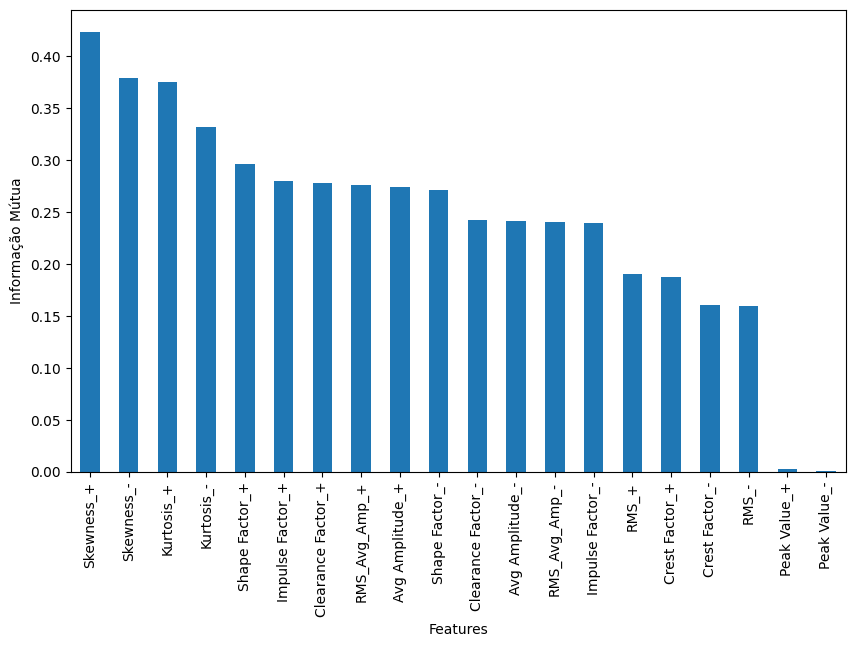

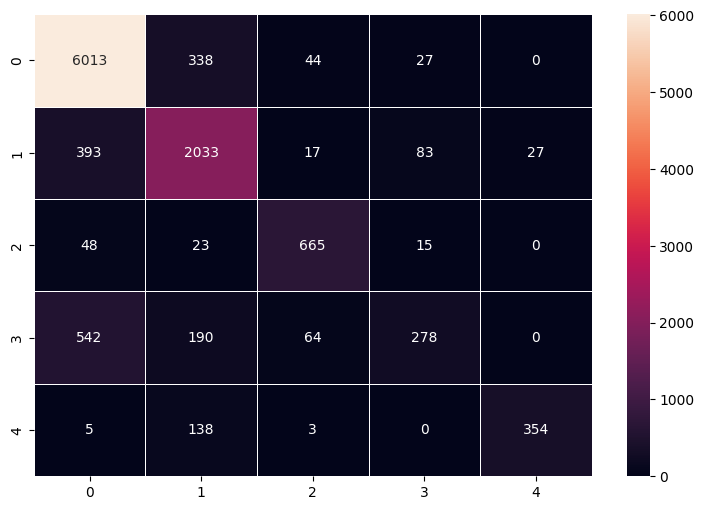

In [ ]:
#Algoritmo de Classificação:

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import RFE
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Splitando os dados em 70/30 para classificação: -- Envelope -- Manual

Env = pd.read_csv(os.path.join(Diretório_Env_Manual, 'Envfeatures_geral_Manual_ALL.csv'), index_col = 0)

Entradas_env = Env.iloc[:, :-1]

Entradas_env = Entradas_env.fillna(0)

Saídas_env = Env.iloc[:, -1]
print(Saídas_env.value_counts())

X_train_env, X_test_env, y_train_env, y_test_env = train_test_split(Entradas_env, Saídas_env, test_size=0.3)

print('-----------------------------------')
print(X_train_env.values.shape)
print(y_train_env.values.shape)
print(X_test_env.values.shape)
print(y_test_env.values.shape)
print('-----------------------------------')

#Aplicando MI
mi_env = mutual_info_classif(X_train_env, y_train_env, discrete_features=False)

mi = pd.Series(mi_env, index=X_train_env.columns)
mi.sort_values(ascending=False).plot.bar(figsize=(10, 6))
plt.xlabel("Features")
plt.ylabel("Informação Mútua")

#print("Informação mútua entre as variáveis de entrada e a variável de saída:")
#print("--------------------------------------------------")
#print(mi_env)


model_env = SVC(kernel='linear', C=1)

#RFE para selecionar as melhores features:
#rfe = RFE(model_env, n_features_to_select=5)  # Selecionar 5 características
#rfe = rfe.fit(X_train_env, y_train_env)
#print("Características selecionadas pelo RFE:")
#print("--------------------------------------------------")
#print(f"Número de características selecionadas:, {rfe.n_features_}")
#print(f"Características selecionadas:, {rfe.support_}")

#Lista das melhores Features -- Manual

#Pelo RFE:
#RMS_+
#Avg_Amplitude_+
#Peak_Value_-
#Avg_Amplitude_-
#RMS_Avg_Amp_-

#Pela MI:
#1-Skewness_+
#2-kurtosis_+
#3-Skewness_-
#4-kurtosis_-
#5-Shape_factor_+


#Selecionando as melhores features com base no MI:
X_train_env = X_train_env.iloc[:, [7,8,9, 18, 19]]
X_test_env = X_test_env.iloc[:, [7,8,9, 18, 19]]



#Testando o modelo:
model_env.fit(X_train_env, y_train_env)
y_pred = model_env.predict(X_test_env)


print("Relatório de Classificação com MI:")
print("--------------------------------------------------")
print(classification_report(y_test_env, y_pred))
print("Acurácia com MI:")
print("--------------------------------------------------")
print(accuracy_score(y_test_env, y_pred))

#Plotagem da matrz de confusão:
f, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(confusion_matrix(y_test_env, y_pred), annot =True, fmt='d', linewidths=0.5, ax=ax)

(874, 34)
(874,)
(375, 34)
(375,)
Relatório de Classificação:
--------------------------------------------------
              precision    recall  f1-score   support

   barra_6kv       0.69      0.68      0.69        73
   euler_cp3       0.61      0.31      0.41        80
   euler_cp5       0.47      0.69      0.56        80
 ponta_ponta       0.55      0.08      0.15        71
     tp_22kv       0.44      0.85      0.58        71

    accuracy                           0.52       375
   macro avg       0.55      0.52      0.48       375
weighted avg       0.55      0.52      0.48       375

Matriz de Confusão:
--------------------------------------------------
[[50  4 11  5  3]
 [ 5 25 13  0 37]
 [ 1  2 55  0 22]
 [16  4 32  6 13]
 [ 0  6  5  0 60]]
Acurácia:
--------------------------------------------------
0.5226666666666666


<Axes: >

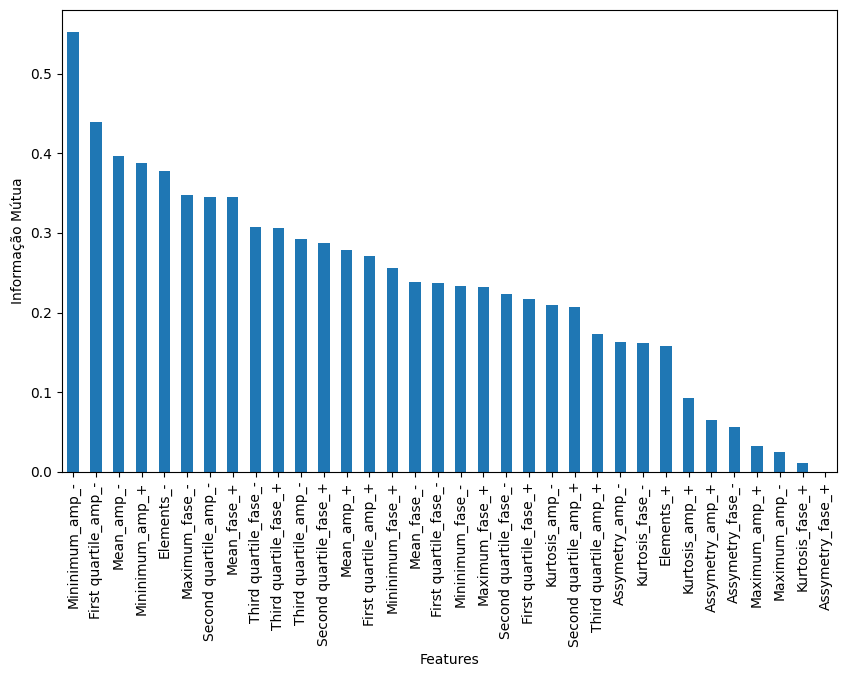

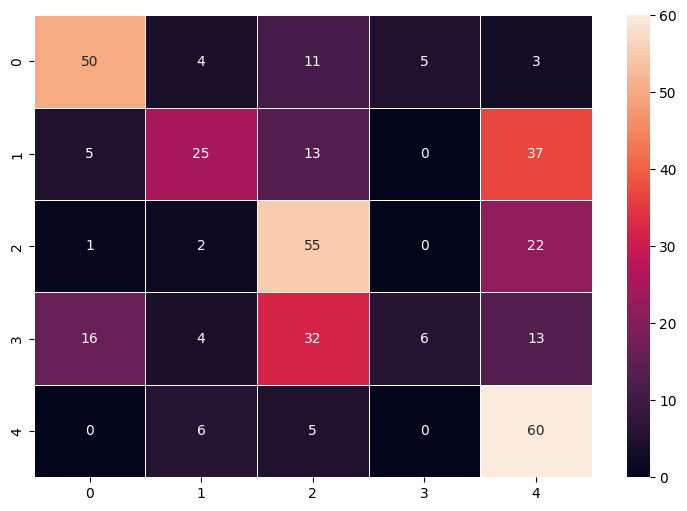

In [ ]:


PRPD = pd.read_csv(os.path.join(Diretório_PRPD, 'PRPDfeatures_geral_ALL.csv'), index_col = 0)

Entradas = PRPD.iloc[:, :-1]

# Coloca valor zero onde há Nan no dataframe das entradas
Entradas = Entradas.fillna(0)

Saídas = PRPD.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(Entradas, Saídas, test_size=0.3, random_state=42)

print(X_train.values.shape)
print(y_train.values.shape)
print(X_test.values.shape)
print(y_test.values.shape)

#Etapa 7 - Aplicando no modelo para treino e teste:

mi = mutual_info_classif(X_train, y_train, discrete_features=False)

#print("Informação mútua entre as variáveis de entrada e a variável de saída:")
#print("--------------------------------------------------")
#print(mi)

mi = pd.Series(mi, index=X_train.columns)
mi.sort_values(ascending=False).plot.bar(figsize=(10, 6))
plt.xlabel("Features")
plt.ylabel("Informação Mútua")


model = SVC(kernel='linear', C=1)

rfe = RFE(model, n_features_to_select=5)  # Selecionar 5 características


rfe = rfe.fit(X_train, y_train)
#print("Características selecionadas pelo RFE:")
#print("--------------------------------------------------")
#print(f"Número de características selecionadas:, {rfe.n_features_}")
#print(f"Características selecionadas:, {rfe.support_}")

#Lista das melhores Features

#Pelo RFE:
#Minimum_fase_+
#First quartile_fase_+
#Minimum_amp_-
#Máximum_amp_-
#Maximum_fase_-

#Pela MI:
#1-Minimum_fase_-
#2-First quartile_fase_-
#3-Minimum_amp_+
#4-Mean_amp_-
#5-Elements_-

#Selecionando as melhores features com base no RFE:
X_train = X_train.iloc[:, [27, 30, 0, 20, 19]]
X_test = X_test.iloc[:, [27, 30, 0, 20, 19]]

#Testando o modelo:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Relatório de Classificação:")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred))
print("Matriz de Confusão:")
print("--------------------------------------------------")
print(confusion_matrix(y_test, y_pred))
print("Acurácia:")
print("--------------------------------------------------")
print(accuracy_score(y_test, y_pred))

f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt="d", linewidths=.5, ax=ax)







In [ ]:
#Splitando os dados em 70/30 para classificação: -- Envelope -- SF

Env = pd.read_csv(os.path.join(Diretório_Env_SF, 'Envfeatures_geral_SF_ALL.csv'), index_col = 0)

Entradas_env = Env.iloc[:, :-1]

Entradas_env = Entradas_env.fillna(0)

Saídas_env = Env.iloc[:, -1]

X_train_env, X_test_env, y_train_env, y_test_env = train_test_split(Entradas_env, Saídas_env, test_size=0.3)

print('-----------------------------------')
print(X_train_env.values.shape)
print(y_train_env.values.shape)
print(X_test_env.values.shape)
print(y_test_env.values.shape)
print('-----------------------------------')

#Aplicando MI
mi_env = mutual_info_classif(X_train_env, y_train_env, discrete_features=False)

mi = pd.Series(mi_env, index=X_train_env.columns)
mi.sort_values(ascending=False).plot.bar(figsize=(10, 6))
plt.xlabel("Features")
plt.ylabel("Informação Mútua")

#print("Informação mútua entre as variáveis de entrada e a variável de saída:")
#print("--------------------------------------------------")
#print(mi_env)


model_env = SVC(kernel='linear', C=1)

#RFE para selecionar as melhores features:
#rfe = RFE(model_env, n_features_to_select=5)  # Selecionar 5 características
#rfe = rfe.fit(X_train_env, y_train_env)
#print("Características selecionadas pelo RFE:")
#print("--------------------------------------------------")
#print(f"Número de características selecionadas:, {rfe.n_features_}")
#print(f"Características selecionadas:, {rfe.support_}")

#Lista das melhores Features

#Pelo RFE:
#RMS_+
#Avg_Amplitude_+
#Peak_Value_-
#Avg_Amplitude_-
#RMS_Avg_Amp_-

#Pela MI:
#1-Skewness_+
#2-Shape_Factor_+
#3-Skewness_-
#4-Shape_Factor_-
#5-RMS_Avg_Amp_+

#Selecionando as melhores features com base no MI:
X_train_env = X_train_env.iloc[:, [3, 7, 8, 17, 18]]
X_test_env = X_test_env.iloc[:, [3, 7, 8, 17, 18]]

#Testando o modelo:
model_env.fit(X_train_env, y_train_env)
y_pred = model_env.predict(X_test_env)

print("Relatório de Classificação com MI:")
print("--------------------------------------------------")
print(classification_report(y_test_env, y_pred))
print("Acurácia com MI:")
print("--------------------------------------------------")
print(accuracy_score(y_test_env, y_pred))

#Plotagem da matrz de confusão:

f, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(confusion_matrix(y_test_env, y_pred), annot = True,fmt='d', linewidths=0.5, ax=ax)